# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [18]:
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, SimpleRNN
from keras.optimizers import Adam

### 1.1 Generating dataset

In [19]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [20]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [21]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [22]:
no_training_epochs = 5

### 1.3 Data examination

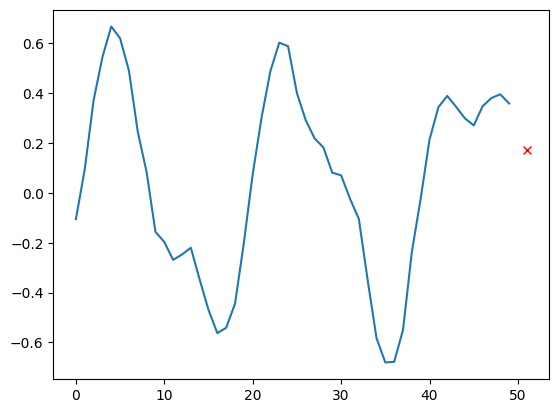

In [23]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [24]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
# Model building

learning_rate = 0.001
optimizer = keras.optimizers.Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [26]:
model_linear.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0798 - mean_squared_error: 0.0798 - val_loss: 0.0323 - val_mean_squared_error: 0.0323
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0228 - mean_squared_error: 0.0228 - val_loss: 0.0148 - val_mean_squared_error: 0.0148
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0092 - val_mean_squared_error: 0.0092
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0073 - val_mean_squared_error: 0.0073
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0065 - val_mean_squared_error: 0.0065


In [28]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

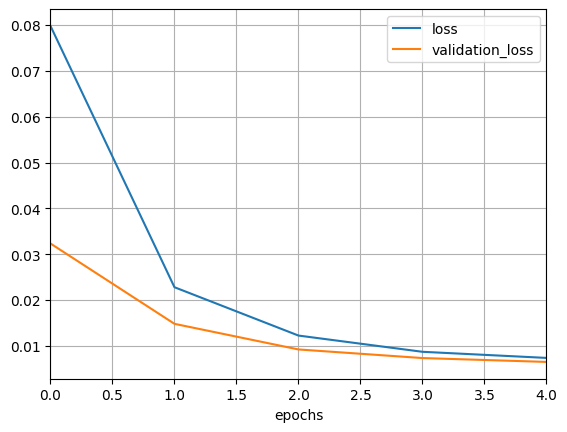

In [29]:
plot_function(history_linear)

In [30]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.006811533588916063
Test MSE:  0.006811533588916063


### 1.5 Simple RNN Model

In [31]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [33]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0147 - mean_squared_error: 0.0147 - val_loss: 0.0121 - val_mean_squared_error: 0.0121
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0116 - val_mean_squared_error: 0.0116
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0115 - val_mean_squared_error: 0.0115
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0114 - val_mean_squared_error: 0.0114
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0114 - val_mean_squared_error: 0.0114


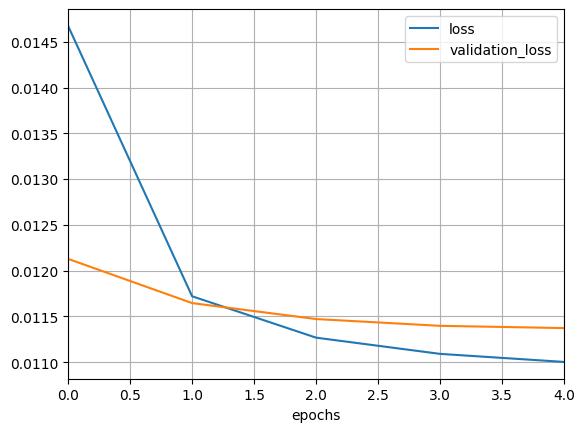

In [34]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [35]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [36]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [37]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0163 - mean_squared_error: 0.0163 - val_loss: 0.0040 - val_mean_squared_error: 0.0040
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0034 - val_mean_squared_error: 0.0034
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0035 - mean_squared_error: 0.0035 - val_loss: 0.0034 - val_mean_squared_error: 0.0034
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0033 - val_mean_squared_error: 0.0033
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0033 - val_mean_squared_error: 0.0033


In [38]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.003431836375966668
Test MSE:  0.003431836375966668


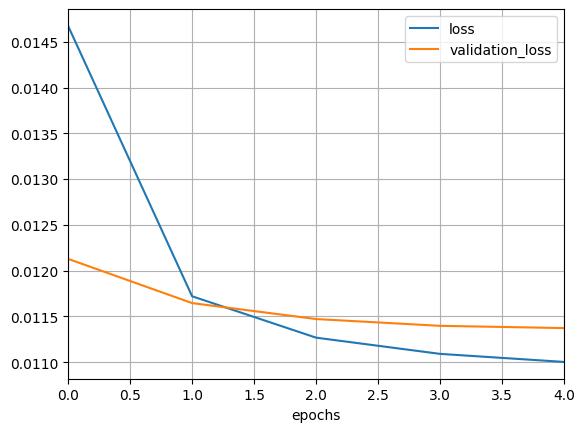

In [39]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [40]:
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU
from keras.optimizers import Adam
from keras.utils import pad_sequences 

### 2.1 - Load dataset

In [41]:
vocabulary_size = 1000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocabulary_size)

### 2.2 - Dataset examination

In [42]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [43]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [44]:
single_sequence

"<sos> this film was just brilliant casting <unk> <unk> story direction <unk> really <unk> the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same <unk> <unk> as myself so i loved the fact there was a real <unk> with this film the <unk> <unk> throughout the film were great it was just brilliant so much that i <unk> the film as soon as it was released for <unk> and would recommend it to everyone to watch and the <unk> <unk> was amazing really <unk> at the end it was so sad and you know what they say if you <unk> at a film it must have been good and this definitely was also <unk> to the two little <unk> that played the <unk> of <unk> and paul they were just brilliant children are often left out of the <unk> <unk> i think because the stars that play them all <unk> up are such a big <unk> for the whole film but these children are amazing and should be <unk> for what they have done don't you

In [45]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [46]:
embed_size = 128



model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


In [47]:
optimizer = Adam(learning_rate = 0.001)

In [48]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [49]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.4977 - loss: 0.7072 - val_accuracy: 0.5062 - val_loss: 0.6950
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4988 - loss: 0.6961 - val_accuracy: 0.5062 - val_loss: 0.6943
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4920 - loss: 0.6957 - val_accuracy: 0.4938 - val_loss: 0.6941
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5072 - loss: 0.6950 - val_accuracy: 0.5062 - val_loss: 0.6940
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5013 - loss: 0.6954 - val_accuracy: 0.5062 - val_loss: 0.6950


In [50]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6958885788917542
Test accuracy:  50.0 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

In [51]:

vocabulary_size = 1000 
embed_size = 128
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocabulary_size)

max_length = 150
X_train = pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

model_lstm = Sequential([
    Embedding(vocabulary_size, embed_size, input_shape=[None]),
    LSTM(128, return_sequences=True),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

optimizer_lstm = Adam(learning_rate = 0.001)
model_lstm.compile(loss="binary_crossentropy", optimizer=optimizer_lstm, metrics=["accuracy"])

history_lstm = model_lstm.fit(X_train, y_train, epochs=5, validation_split=0.2)




Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5344 - loss: 0.6882 - val_accuracy: 0.5902 - val_loss: 0.6770
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5949 - loss: 0.6636 - val_accuracy: 0.5764 - val_loss: 0.6628
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7373 - loss: 0.5381 - val_accuracy: 0.7888 - val_loss: 0.4651
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8104 - loss: 0.4167 - val_accuracy: 0.8162 - val_loss: 0.4045
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8368 - loss: 0.3748 - val_accuracy: 0.8190 - val_loss: 0.4144


In [53]:

vocabulary_size = 1000 
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocabulary_size)

max_length = 150
X_train = pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

model_gru = Sequential([
    Embedding(vocabulary_size, embed_size, input_shape=[None]),
    GRU(128, return_sequences=True),
    GRU(128),
    Dense(1, activation='sigmoid')
])
optimizer_gru = Adam(learning_rate = 0.001)
model_gru.compile(loss="binary_crossentropy", optimizer=optimizer_gru, metrics=["accuracy"])
history_gru = model_gru.fit(X_train, y_train, epochs=5, validation_split=0.2)
score = model_gru.evaluate(X_test, y_test, verbose=0)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5429 - loss: 0.6902 - val_accuracy: 0.5064 - val_loss: 0.6726
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7205 - loss: 0.5592 - val_accuracy: 0.7572 - val_loss: 0.5048
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7897 - loss: 0.4540 - val_accuracy: 0.7878 - val_loss: 0.4524
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8289 - loss: 0.3795 - val_accuracy: 0.8238 - val_loss: 0.3926
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8454 - loss: 0.3489 - val_accuracy: 0.8350 - val_loss: 0.3796


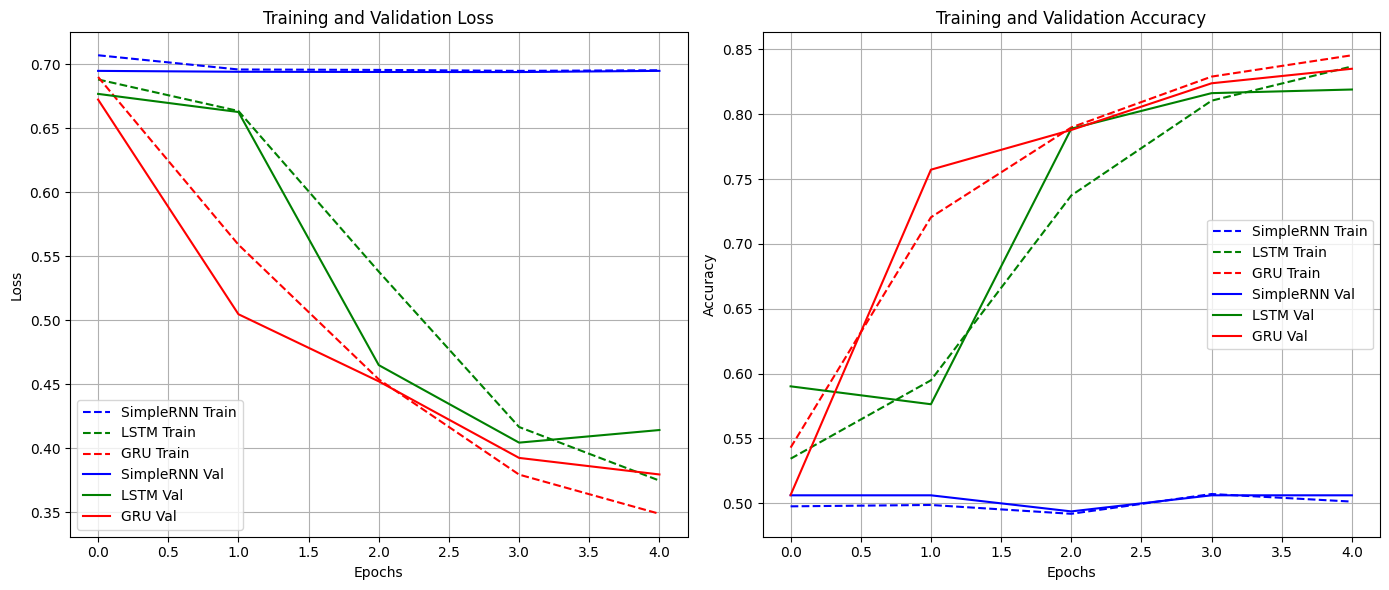

--- Final Test Set Performance ---
SimpleRNN - Loss: 0.6959, Accuracy: 50.00%
LSTM      - Loss: 0.3989, Accuracy: 81.81%
GRU       - Loss: 0.3676, Accuracy: 83.20%


In [54]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='SimpleRNN Train', color='blue', linestyle='--')
plt.plot(history_lstm.history['loss'], label='LSTM Train', color='green', linestyle='--')
plt.plot(history_gru.history['loss'], label='GRU Train', color='red', linestyle='--')
plt.plot(history.history['val_loss'], label='SimpleRNN Val', color='blue')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val', color='green')
plt.plot(history_gru.history['val_loss'], label='GRU Val', color='red')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='SimpleRNN Train', color='blue', linestyle='--')
plt.plot(history_lstm.history['accuracy'], label='LSTM Train', color='green', linestyle='--')
plt.plot(history_gru.history['accuracy'], label='GRU Train', color='red', linestyle='--')
plt.plot(history.history['val_accuracy'], label='SimpleRNN Val', color='blue')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val', color='green')
plt.plot(history_gru.history['val_accuracy'], label='GRU Val', color='red')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("--- Final Test Set Performance ---")
score_rnn = model.evaluate(X_test, y_test, verbose=0)
print(f"SimpleRNN - Loss: {score_rnn[0]:.4f}, Accuracy: {score_rnn[1]*100:.2f}%")

score_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f"LSTM      - Loss: {score_lstm[0]:.4f}, Accuracy: {score_lstm[1]*100:.2f}%")

score_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print(f"GRU       - Loss: {score_gru[0]:.4f}, Accuracy: {score_gru[1]*100:.2f}%")